<a target="_blank" href="https://colab.research.google.com/github/aadhyabansal/rag-eval-harness/blob/main/rag_eval_harness.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# RAG Evaluation Harness

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install wikipedia-api

In [5]:
import os

drive_path= '/content/drive/MyDrive/rag_eval_harness'
os.makedirs(drive_path, exist_ok=True)

data= os.path.join(drive_path, 'data')
os.makedirs(data, exist_ok=True)

raw_data= os.path.join(data, 'raw_data')
os.makedirs(raw_data, exist_ok=True)

chunk_path=os.path.join(data, "chunks.json")

## Phase 1: Fetch + clean the corpus

In [ ]:
import wikipediaapi
import re

Articles=["Gradient descent",
          "Backpropogation",
          "Loss function",
          "Overfitting",
          "Regularization (mathematics)",
          "Cross-validation (statistics)",
          "Hyperparameter optimization",
          "Bias-variance tradeoff",
          "Convolutional neural network",
          "Recurrent neural network",
          "Long short-term memory",
          "Transformer (deep learning architecture)",
          "Attention (machine learning)",
          "Autoencoder",
          "Generative adversarial network",
          "Word embedding",
          "BERT (language model)",
          "GPT (language model)",
          "Byte-pair encoding",
          "Geoffrey Hinton",
          "Yann LeCun",
          "Yoshua Bengio",
          "History of artificial neural networks",
          "AlexNet",
          "Supervised learning",
          "Unsupervised learning",
          "Reinforcement learning",
          "Support vector machine",
          ]

wiki= wikipediaapi.Wikipedia(user_agent="rag_eval_harness", language="en")

def clean_text(text : str) -> str:
  text= re.sub(r"\n{3,}","\n\n",text)
  text= re.sub(r"[\t]+", " ", text)
  return text.strip()

def clean_math_notations(text : str) -> str:
  text= re.sub(r"\{\\displaystyle.*?\}", "[FORMULA]" , text)
  text= re.sub(r"\\[a-zA-Z]+", "", text)
  text= re.sub(r"[{}]", "" , text)
  text = re.sub(r"[∇∂≈≠≤≥±×÷√∑∏∫‖∈∀∃]", "", text)
  text= re.sub(r"\s{2,}", " ", text)
  return text.strip()

def strip_unimportant(text : str) -> str:
  cutoff_marks=["\nSee also\n",
                "\nReferences\n",
                "\nBibliography\n",
                "\nFurther reading\n",
                "\nExternal links\n",
                "\nNotes\n"
                ]
  cutoff_idx= len(text)
  for mark in cutoff_marks:
    idx = text.find(mark)

    if idx != -1:
      cutoff_idx= min(cutoff_idx, idx)

  return text[:cutoff_idx].strip()

def slugify(title : str) -> str :
  return re.sub(r"[^a-z0-9]", "_", title.lower()).strip("_")

skip=[]
fetched=[]

for title in Articles:
  page= wiki.page(title)

  if not page.exists():
    skip.append(title)
    print(f"{title} not found. Skipped")
    continue

  text= clean_text(page.text)
  text= strip_unimportant(text)
  text= clean_math_notations(text)

  if(len(text)<500):
    skip.append(title)
    print(f"{title} too short. Skipped")
    continue

  new_title= slugify(title)

  filepath= os.path.join(raw_data, f"{new_title}.txt")

  with open (filepath, 'w', encoding='utf-8') as f:
    f.write(text)

  fetched.append(f"title: {title} , slug: {new_title} , chars: {len(text)}")

  print(f"Okayyy {title} -> {new_title}.txt ({len(text)} chars)")

print(f"Skipped : {len(skip)}")
print(f"Fetched : {len(fetched)}")


Okayyy Gradient descent -> gradient_descent.txt (22689 chars)
Okayyy Backpropogation -> backpropogation.txt (29663 chars)
Okayyy Loss function -> loss_function.txt (12841 chars)
Okayyy Overfitting -> overfitting.txt (14897 chars)
Okayyy Regularization (mathematics) -> regularization__mathematics.txt (20487 chars)
Okayyy Cross-validation (statistics) -> cross_validation__statistics.txt (27081 chars)
Okayyy Hyperparameter optimization -> hyperparameter_optimization.txt (10270 chars)
Okayyy Bias-variance tradeoff -> bias_variance_tradeoff.txt (17515 chars)
Okayyy Convolutional neural network -> convolutional_neural_network.txt (61149 chars)
Okayyy Recurrent neural network -> recurrent_neural_network.txt (35236 chars)
Okayyy Long short-term memory -> long_short_term_memory.txt (14730 chars)
Okayyy Transformer (deep learning architecture) -> transformer__deep_learning_architecture.txt (58825 chars)
Okayyy Attention (machine learning) -> attention__machine_learning.txt (12941 chars)
Okayyy A

In [ ]:
with open ('/content/drive/MyDrive/rag_eval_harness/data/raw_data/backpropogation.txt' , 'r') as f:
  print(f.read()[-1000:])

autonomously using backpropagation.
The LeNet was published in 1989 to recognize handwritten zip codes.
In 1992, TD-Gammon achieved top human level play in backgammon. It was a reinforcement learning agent with a neural network with two layers, trained by backpropagation.
In 1993, Eric Wan won an international pattern recognition contest through backpropagation. After backpropagation
During the 2000s it fell out of favour, but returned in the 2010s, benefiting from cheap, powerful GPU-based computing systems. This has been especially so in speech recognition, machine vision, natural language processing, and language structure learning research (in which it has been used to explain a variety of phenomena related to first and second language learning.)
Error backpropagation has been suggested to explain human brain event-related potential (ERP) components like the N400 and P600.
In 2023, a backpropagation algorithm was implemented on a photonic processor by a team at Stanford University.

In [ ]:
!pip install langchain-text-splitters

## Phase 2: Chunk + embed

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter= RecursiveCharacterTextSplitter(
    chunk_size= 800,
    chunk_overlap= 100,
    separators=["\n\n","\n","."," ",""],
)

all_chunks=[]
chunk_id_counter=0

for file in sorted(os.listdir(raw_data)):

  if not file.endswith(".txt"):
    continue

  slug= file.replace(".txt","")
  file_path= os.path.join(raw_data, file)

  with open (file_path, 'r', encoding='utf-8') as f:
    text=f.read()

  chunks= splitter.split_text(text)

  for i, chunk_text in enumerate(chunks):

    chunk_id= f"chunk_{chunk_id_counter:04d}"

    all_chunks.append({
        "id" : chunk_id,
        "slug" : slug,
        "chunk_idx" : i,
        "text" : chunk_text,
    })

    chunk_id_counter+=1

  print(f"{slug}: {len(chunks)} chunks")

print(f"\nTotal chunks: {len(all_chunks)}")

alexnet: 20 chunks
attention__machine_learning: 25 chunks
autoencoder: 43 chunks
backpropogation: 54 chunks
bert__language_model: 28 chunks
bias_variance_tradeoff: 33 chunks
byte_pair_encoding: 9 chunks
convolutional_neural_network: 109 chunks
cross_validation__statistics: 52 chunks
generative_adversarial_network: 84 chunks
geoffrey_hinton: 31 chunks
gpt__language_model: 25 chunks
gradient_descent: 38 chunks
history_of_artificial_neural_networks: 48 chunks
hyperparameter_optimization: 17 chunks
long_short_term_memory: 25 chunks
loss_function: 24 chunks
overfitting: 25 chunks
recurrent_neural_network: 63 chunks
regularization__mathematics: 39 chunks
reinforcement_learning: 64 chunks
supervised_learning: 31 chunks
support_vector_machine: 60 chunks
transformer__deep_learning_architecture: 108 chunks
unsupervised_learning: 26 chunks
word_embedding: 18 chunks
yann_lecun: 13 chunks
yoshua_bengio: 18 chunks

Total chunks: 1130


In [ ]:
all_chunks[-2:]

[{'id': 'chunk_1128',
  'slug': 'yoshua_bengio',
  'chunk_idx': 16,
  'text': 'Dzmitry Bahdanau; Kyunghyun Cho; Yoshua Bengio (2014). "Neural Machine Translation by Jointly Learning to Align and Translate". arXiv:1409.0473 [cs.CL].\nLéon Bottou, Patrick Haffner, Paul G. Howard, Patrice Simard, Yoshua Bengio, Yann LeCun: High Quality Document Image Compression with DjVu Archived May 10, 2020, at the Wayback Machine, In: Journal of Electronic Imaging, Band 7, 1998, S. 410–425 doi:10.1117/1.482609\nBengio, Yoshua; Schuurmans, Dale; Lafferty, John; Williams, Chris K. I. and Culotta, Aron (eds.), Advances in Neural Information Processing Systems 22 (NIPS\'22), December 7th–10th, 2009, Vancouver, BC, Neural Information Processing Systems (NIPS) Foundation, 2009'},
 {'id': 'chunk_1129',
  'slug': 'yoshua_bengio',
  'chunk_idx': 17,
  'text': 'Y. Bengio, Dong-Hyun Lee, Jorg Bornschein, Thomas Mesnard, Zhouhan Lin: Towards Biologically Plausible Deep Learning, arXiv.org, 2016\nBengio contribute

storing as json

In [ ]:
import json
with open (chunk_path, 'w', encoding='utf-8') as f:
  json.dump(all_chunks, f, indent=2)
  print(f"Saved chunks to {chunk_path}")

In [ ]:
!pip install sentence-transformers chromadb

**Setting up chroma database and collection object**

Chunks are embedded locally with all-MiniLM-L6-v2 and stored in Chroma

In [7]:
from sentence_transformers import SentenceTransformer
import chromadb

with open(chunk_path, 'r', encoding='utf-8') as f:
  chunks= json.load(f)

print(f"Loaded {len(chunks)} chunks")

model= SentenceTransformer('all-MiniLM-L6-v2')

db_path=os.path.join(data,"chroma_database")

os.makedirs(db_path, exist_ok=True)
print(f"Ensured {db_path} directory exists.")

client= chromadb.PersistentClient(path=db_path)
collection= client.get_or_create_collection(name="chunk_collection")

texts= [c["text"] for c in chunks]
ids= [c['id'] for c in chunks]
metadatas= [{'slug' : c['slug'], 'chunk_idx' : c['chunk_idx']} for c in chunks]

print("Embeddingsss....")
embeddings= model.encode(texts, show_progress_bar=True, batch_size=64)

collection.add(ids=ids, embeddings=embeddings.tolist(), documents=texts, metadatas=metadatas)

print(f"Stored {collection.count()} in chroma")

Loaded 1130 chunks


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Ensured /content/drive/MyDrive/rag_eval_harness/data/chroma_database directory exists.
Embeddingsss....


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Stored 1130 in chroma


In [ ]:
def browse_doc(slug : str, limit : int = 30):
  req_chunks= [c for c in chunks if c['slug']==slug]

  req_chunks.sort(key= lambda c: c['chunk_idx'])

  for c in req_chunks[::]:
    print(f"---{c['id']}---")
    print(c['text'][:1000], "...\n")

# browse_doc("convolutional_neural_network")


## Phase 3: Build the eval set

In [6]:
import pandas as pd

#category : direct, multi_chunk_compare, multi_chunk_aggregation, ambiguous, ambiguous_aggregation, leading_question, unanswerable
eval_questions=[
    {
        "question" : "what is the challenge associated with choosing the step size in gradient descent?",
        "correct_chunk_id" : ["chunk_0521"],
        "correct_answer" : "If step size is too small, it would slow convergence, the opposite would lead to overshoot and divergence therefore it is crucial to found middle ground.",
        "category" : "direct"
    },
    {
        "question" :"what two conditions must be fulfilled by mathematical expression of loss function?",
        "correct_chunk_id" : ["chunk_0130"],
        "correct_answer" : "it can be written as average and it can be written as function of the outputs from the neural network.",
        "category" : "direct"
    },
    {
        "question" : "What are the two very commonly used loss functions in machine learning?",
        "correct_chunk_id" : ["chunk_0661"],
        "correct_answer" : "Squared loss and absolute loss.",
        "category" : "direct"

    },
    {
        "question" : "What is overfitting and how is it related to underfitting?",
        "correct_chunk_id" : ["chunk_0665", "chunk_0684"],
        "correct_answer" : """Overfitting occurs when a model learns the training data too closely,
                      including its noise, so it performs well on training data but poorly on unseen data.
                      Underfitting is the opposite, the model fails to capture the underlying pattern,
                      performing poorly on both training and test data.""",

        "category" : "multi_chunk_compare"
    },
    {
        "question" : "what is the purpose of regularization in machine learning?",
        "correct_chunk_id" : ["chunk_0759"],
        "correct_answer" : """The main purpose of regularization in machine learning is to prevent overfitting
        and improve a model's ability to generalize to new, unseen data""",

        "category" : "direct"
    },
    {
        "question" : "Differentiate between exhaustive and non-exhaustive cross-validation.",
        "correct_chunk_id" : ["chunk_0329", "chunk_0333"],
        "correct_answer" : """Exhaustive methods learn and test on all possible ways to divide the original sample
         into a training set and a validation set whereas Non-exhaustive methods do not compute all possible ways
         of splitting the original sample, they act as approximations of the exhaustive approach to save
         time and computing power""",

        "category" : "multi_chunk_compare"
    },
    {
        "question" : "List all the approaches for hyperparameter optimization.",
        "correct_chunk_id" : ["chunk_0600", "chunk_0603", "chunk_0604", "chunk_0606", "chunk_0609", "chunk_0610", "chunk_0612"],
        "correct_answer" : "Grid search, Random Search, Bayesian Optimization, Gradient-based optimization, Evolutionary optimization, Population-based, Early stopping-based",
        "category" : "multi_chunk_aggregation"
    },
    {
        "question" :"State the various applications of bias-variance decomposition.",
        "correct_chunk_id" : ["chunk_0196", "chunk_0197", "chunk_0198", "chunk_0199", "chunk_0200"],
        "correct_answer" : "In regression, In classification, In reinforcement learning, In Monte Carlo methods, In human learning",
        "category" : "multi_chunk_aggregation"
    },
    {
        "question" : "Which type of pooling performs better in practice?",
        "correct_chunk_id" : ["chunk_0271"],
        "correct_answer" : "Max-pooling",
        "category" : "direct"
    },
    {
        "question" : "What are NTMs? Explain in brief.",
        "correct_chunk_id" : ["chunk_0719"],
        "correct_answer" : """Neural Turing machines (NTMs) are a method of extending recurrent neural networks by combining
        their learning ability with an external memory, allowing the model to store, retrieve, and manipulate information.""",

        "category" : "direct"
    },
    {
        "question" : "In what year Graves and Schmidhuber published LSTM with full backpropagation?",
        "correct_chunk_id" : ["chunk_0636"],
        "correct_answer" : "2005",
        "category" : "direct"
    },
    {
        "question" : "What are the two ways by which a Multimodal model can be trained?",
        "correct_chunk_id" : ["chunk_1049"],
        "correct_answer" : "from scratch and from fine tuning",
        "category" : "direct"
    },
    {
        "question" : "What are hard weights and soft weights?",
        "correct_chunk_id" :["chunk_0021"],
        "correct_answer" : "Hard weights are computed during backword pass and soft weights are computed during forward pass and change during each step.",
        "category" : "direct"
    },
    {
        "question" : "What are the two main applications of autoencoders?",
        "correct_chunk_id" : ["chunk_0074"],
        "correct_answer" : "dimensionality reduction and information retrieval",
        "category" : "direct"
    },
    {
        "question" : "How many women reaserchers were involved in the launch event of GPT-4?",
        "correct_chunk_id" : [],
        "correct_answer" : "NONE - not present in this document corpus",
        "category" : "unanswerable"
    },
    {
        "question" : "How does BPE algorithm works?",
        "correct_chunk_id" : ["chunk_0204"],
        "correct_answer" : """BPE operates by iteratively replacing the most common contiguous
        sequences of characters in a target text with unused bytes. The iteration ends when no sequences
        can be found resulting in a compressed target text.""",
        "category" : "direct"
    },
    {
        "question" : "Who is Yann Lecun? Why is he famous?",
        "correct_chunk_id" : ["chunk_1099", "chunk_1100"],
        "correct_answer" : """Yann Lecun is a French-American computer scientist. He is famous for
        his work on optical character recognition and computer vision using convolutional neural networks.""",

        "category" : "multi_chunk_compare"
    },
    {
        "question" : "Who founded LawZero?",
        "correct_chunk_id" : ["chunk_1121"],
        "correct_answer" : "Yoshua Bengio",
        "category" : "direct"
    },
    {
        "question" : "How did the paper 'Man is to Computer Programmer as Woman is to Homemaker? Debiasing Word Embeddings' highlighted the bias in word analogies?",
        "correct_chunk_id": [],
        "correct_answer": "NONE - not present in this document corpus",
        "category" : "unanswerable"
    },
    {
        "question" : "What is one of the main limitations of static word vector space models?",
        "correct_chunk_id" : ["chunk_1089"],
        "correct_answer" : "words with multiple meanings are conflated into a single representation.",
        "category" : "direct"
    },
    {
        "question": "What is the exact FLOPs count required to train GPT-4?",
        "correct_chunk_id": [],
        "correct_answer": "NONE - not present in this document corpus",
        "category" : "unanswerable"
    },
    {
        "question" : "How does AlexNet differ from LeNet?",
        "correct_chunk_id" : ["chunk_0018"],
        "correct_answer" : """AlexNet and LeNet share essentially the same design and algorithm but AlexNet is much larger than LeNet
        and was trained on a much larger dataset on much faster hardware""",
        "category" : "direct"
    },
    {
        "question" : "Which branch of machine learning groups the data that has not been labelled?",
        "correct_chunk_id" : ["chunk_1074"],
        "correct_answer" : "Cluster analysis",
        "category" : "direct"
    },
    {
        "question" : "What are four major issues to consider in supervised learning?",
        "correct_chunk_id" : ["chunk_0861", "chunk_0863", "chunk_0864", "chunk_0866"],
        "correct_answer" : "Bias–variance tradeoff, Function complexity and amount of training data, Dimensionality of the input space, Noise in the output values",
        "category" : "multi_chunk_aggregation"

    },
    {
        "question": "How is AlexNet better than LeNet?",
        "correct_chunk_id": ["chunk_0018"],
        "correct_answer": "The source doesn't frame this as AlexNet being 'better' but it describes differences: AlexNet shares LeNet's basic design but is larger, trained on a much bigger dataset, and used much faster hardware.",
        "category": "leading_question"
    },
    {
        "question" : "What does the term 'supervised' mean in supervied learning?",
        "correct_chunk_id" : ["chunk_0856"],
        "correct_answer" : "Supervised means supervising or training the model to learn new patterns, it refers to a role that of a teacher or a supervisor.",
        "category" : "direct"
    },
    {
        "question" : "When did google launch Gemini?",
        "correct_chunk_id" : [],
        "correct_answer": "NONE - not present in this document corpus",
        "category" : "unanswerable"
    },
    {
        "question" : "Describe the core idea of GAN.",
        "correct_chunk_id" : ["chunk_0375"],
        "correct_answer" : """The core idea of GAN is based on indirect training through a discriminator that
         can tell how realistic the output seems, which means the generator is not trained to minimize the
         distance to a specific image, but rather to fool the discriminator. This enables the model to learn in an unsupervised manner""",
        "category" : "direct"
    },
    {
        "question" : "How did Geoffrey's views in 2023 contradicted his earlier views?",
        "correct_chunk_id" : ["chunk_0478"],
        "correct_answer": """Hinton previously estimated AGI was 30-50+ years away, but in a March 2023 CBS interview he shifted to saying
        general-purpose AI could arrive in under 20 years, comparing its potential impact to the industrial revolution or the advent of electricity.""",

        "category" : "direct"
    },
    {
        "question" : "What are neurological networks?",
        "correct_chunk_id" : [],
        "correct_answer" : "NONE - not present in this document corpus",
        "category" : "unanswerable"
    },
    {
        "question": "Was the risk of gradient descent getting stuck in a local minimum considered a fatal flaw for training neural networks with backpropagation?",
        "correct_chunk_id": ["chunk_0132"],
        "correct_answer": "It was long considered a major drawback, since gradient descent with backpropagation isn't guaranteed to reach the global minimum. However, Yann LeCun and colleagues argued that in many practical problems this isn't actually a significant issue.",
        "category": "direct"
    },
    {
        "question" : "What happened on October 25, 2019?",
        "correct_chunk_id" : ["chunk_0164"],
        "correct_answer" : "Google announced they are effectively applying BERT in google search within the US",
        "category" : "direct"
    },
    {
        "question" : "How did google help in the production of GPT?",
        "correct_chunk_id" : ["chunk_0491"],
        "correct_answer" : "Google didn't help in the production of GPT directly though GPT is based on the transformer architecture developed by google",
        "category" : "leading_question"
    },
    {
        "question" : "List the applications of the neural networks which are used where the order of elements is important",
        "correct_chunk_id" : ["chunk_0751", "chunk_0752"],
        "correct_answer" : """Machine translation, Robot control, Time series prediction, Speech recognition, Speech synthesis,
          Brain–computer interfaces, Time series anomaly detection, Text-to-Video model, Energy forecasting, Rhythm learning, Music composition,
          Grammar learning, Handwriting recognition, Human action recognition, Protein homology detection,
          Predicting subcellular localization of proteins, Several prediction tasks in the area of business process management,
          Prediction in medical care pathways, Predictions of fusion plasma disruptions in reactors (Fusion Recurrent Neural Network (FRNN) code)""",

        "category" : "ambiguous_aggregation"
    },
     {
        "question" : "What earlier architectural innovation, introduced by a different research group, does GPT's design build on?",
        "correct_chunk_id" : ["chunk_0491"],
        "correct_answer" : "Transformer architecture developed by google introduced in 'Attention is all you need'.",
        "category" : "ambiguous"
    },
    {
        "question" : "What are the ethical and societal concerns raised by large language models based on transformer?",
        "correct_chunk_id" : ["chunk_0511"],
        "correct_answer" : "bias, misinformation, and environmental impact.",
        "category" : "direct"
    },
    {
        "question" : "What is the purpose of approximate dynamic programming?",
        "correct_chunk_id" : ["chunk_0797"],
        "correct_answer" : "The purpose of approximate dynamic programming is for the agent to learn an optimal policy that maximizes the reward function.",
        "category" : "ambiguous"
    },
    {
        "question" : "What are some drawbacks of SVM?",
        "correct_chunk_id" : ["chunk_0934"],
        "correct_answer" : "Requires full labeling of input data, avoids estimating probabilities on finite data, only directly applicable for two-class tasks, parameters of a solved model are difficult to interpret",
        "category" : "direct"
    },
    {
        "question": "Does the size of each update taken during optimization actually influence how well the model converges?",
        "correct_chunk_id": ["chunk_0521"],
        "correct_answer": "Yes, it matters significantly. Too small a step size slows convergence, while too large a step size can cause overshoot and divergence — finding the right middle ground is crucial.",
        "category": "ambiguous"
    },
    {
        "question" : "Explain the working of the layer proposed by Alston Householder?",
        "correct_chunk_id" : ["chunk_0274"],
        "correct_answer" : "Alston Householder proposed ReLU. It effective removes negative values by setting them to zero.",
        "category" : "ambiguous"
    }
]

df= pd.DataFrame(eval_questions)
df.to_csv("/content/drive/MyDrive/rag_eval_harness/data/eval_questions.csv", index=False)
print(df)

                                             question  \
0   what is the challenge associated with choosing...   
1   what two conditions must be fulfilled by mathe...   
2   What are the two very commonly used loss funct...   
3   What is overfitting and how is it related to u...   
4   what is the purpose of regularization in machi...   
5   Differentiate between exhaustive and non-exhau...   
6   List all the approaches for hyperparameter opt...   
7   State the various applications of bias-varianc...   
8   Which type of pooling performs better in pract...   
9                    What are NTMs? Explain in brief.   
10  In what year Graves and Schmidhuber published ...   
11  What are the two ways by which a Multimodal mo...   
12            What are hard weights and soft weights?   
13  What are the two main applications of autoenco...   
14  How many women reaserchers were involved in th...   
15                      How does BPE algorithm works?   
16               Who is Yann Le

# 1. Embeddings Strategy evaluation

## Phase 4: Embeddings retrieval + generation + judging

Defining a chunk retrieval function

In [22]:
def retrieve(query : str, top_k: int =5) -> list:
  query_embedding= model.encode([query])[0]
  results = collection.query(query_embeddings=[query_embedding.tolist()], n_results=top_k)

  retrieved=[]

  for i in range(len(results['ids'][0])):
    retrieved.append({
        'id' : results['ids'][0][i],
        'text' : results['documents'][0][i],
        'slug' : results['metadatas'][0][i]['slug'],
        'distance' : results['distances'][0][i],
        })

  return retrieved

test= retrieve("What is backpropogation?")

for r in test:
  print(f"[{r['id']}] ({r['slug']}) dist= {r['distance']}")
  print(r['text'][:200], "....\n")

[chunk_0088] (backpropogation) dist= 0.5726293921470642
In machine learning, backpropagation is a gradient computation method commonly used for training a neural network in computing parameter updates.
It is an efficient application of the chain rule to ne ....

[chunk_0564] (history_of_artificial_neural_networks) dist= 0.5734384655952454
. Backpropagation ....

[chunk_0089] (backpropogation) dist= 0.5744631290435791
Strictly speaking, the term backpropagation refers only to an algorithm for efficiently computing the gradient, not how the gradient is used, but the term is often used loosely to refer to the entire  ....

[chunk_0090] (backpropogation) dist= 0.7378028631210327
Backpropagation computes the gradient in weight space of a feedforward neural network, with respect to a loss function. Denote: x [FORMULA] : input (vector of features) y [FORMULA] : target output
For ....

[chunk_0099] (backpropogation) dist= 0.739728569984436
Backpropagation can be expressed for simple feedforwar

Evaluating retrieval

In [69]:
import ast
import pandas as pd

eval_set= pd.read_csv("/content/drive/MyDrive/rag_eval_harness/data/eval_questions.csv")

def check_retrieval(row, top_k : int = 5):

  category= row['category']
  if category == "ambiguous" or category == "ambiguous_aggregation" or category=="multi_chunk_aggregaion":
    top_k=20

  retrieved= retrieve(row['question'], top_k=top_k)
  retrieved_chunks= [r['id'] for r in retrieved]

  correct_chunks= ast.literal_eval(row['correct_chunk_id'])
  hits= [cid for cid in retrieved_chunks if cid in correct_chunks]

  return {
      'retrieved_chunks' : retrieved_chunks,
      'correct_expected' : len(correct_chunks),
      'correct_found' : len(hits),
      'full_recall' : len(hits)== len(correct_chunks),
      'partial_recall' : len(hits) > 0,
  }

results= eval_set.apply(lambda d: check_retrieval(d), axis=1)
results= pd.json_normalize(results.dropna())

eval_set= eval_set.join(results)

In [13]:
print(eval_set[["question", "category", "correct_expected", "correct_found", "full_recall", "partial_recall"]])

                                             question  \
0   what is the challenge associated with choosing...   
1   what two conditions must be fulfilled by mathe...   
2   What are the two very commonly used loss funct...   
3   What is overfitting and how is it related to u...   
4   what is the purpose of regularization in machi...   
5   Differentiate between exhaustive and non-exhau...   
6   List all the approaches for hyperparameter opt...   
7   State the various applications of bias-varianc...   
8   Which type of pooling performs better in pract...   
9                    What are NTMs? Explain in brief.   
10  In what year Graves and Schmidhuber published ...   
11  What are the two ways by which a Multimodal mo...   
12            What are hard weights and soft weights?   
13  What are the two main applications of autoenco...   
14  How many women reaserchers were involved in th...   
15                      How does BPE algorithm works?   
16               Who is Yann Le

Setting up environment for LLM calls using groq API

In [71]:
!pip install groq

from groq import Groq
import time

client = Groq(api_key= userdata.get('API'))

def call_llm(prompt: str, model: str = "llama-3.3-70b-versatile") -> str:
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    return response.choices[0].message.content.strip()

Generating answers **ONLY** from the context provided

In [72]:
def generate_answer(question, retrieved_chunks):

  context= "\n\n".join([c["text"] for c in retrieved_chunks])

  prompt= f""" Answer the question using ONLY on the context provided below. If the context does not contain the answer, say "I don't know based on the given context."
Do not use outside knowledge.

Context : {context}

question : {question}

Answer : """
  return call_llm(prompt)



Using LLM to judge the generated answer against correct answer

In [73]:
def llm_as_judge(question, generated_ans, correct_ans):

  prompt= f""" You are grading whether an answer is correct or not.

  Question : {question}
  Correct answer : {correct_ans}
  Generated answer : {generated_ans}

  Return the grade as one word : CORRECT, PARTIAL OR WRONG. """

  return call_llm(prompt)

In [9]:
def get_top_k(category):
  if category in ["ambiguous" , "ambiguous_aggregation", "multi_chunk_aggregation"] :
    return 10
  return 5

Getting final results for answers with the judgement as CORRECT, PARTIAL, or WRONG

In [78]:
import time

final_results=[]

for idx, row in eval_set.iterrows():
  top_k= get_top_k(row['category'])

  retrieved= retrieve(row['question'], top_k=top_k)
  generated= generate_answer(row['question'], retrieved)

  judgement= llm_as_judge(row['question'], generated, row['correct_answer'])

  final_results.append(
      {
          'question' : row['question'],
          'category' : row['category'],
          'top_chunks_used' : top_k,
          'generated_answer' : generated,
          'judgement' : judgement,
      }
  )

  time.sleep(10)

  print(f"[{idx}] top_k={top_k} {row['category']} {judgement} — {row['question'][:60]}")


results_final_df = pd.DataFrame(final_results)
eval_set = eval_set.join(results_final_df[['top_chunks_used', "generated_answer", "judgement"]])


[0] top_k=5 direct WRONG — what is the challenge associated with choosing the step size
[1] top_k=5 direct CORRECT — what two conditions must be fulfilled by mathematical expres
[2] top_k=5 direct PARTIAL — What are the two very commonly used loss functions in machin
[3] top_k=5 multi_chunk_compare CORRECT — What is overfitting and how is it related to underfitting?
[4] top_k=5 direct CORRECT — what is the purpose of regularization in machine learning?
[5] top_k=5 multi_chunk_compare PARTIAL — Differentiate between exhaustive and non-exhaustive cross-va
[6] top_k=10 multi_chunk_aggregation CORRECT — List all the approaches for hyperparameter optimization.
[7] top_k=10 multi_chunk_aggregation CORRECT — State the various applications of bias-variance decompositio
[8] top_k=5 direct CORRECT — Which type of pooling performs better in practice?
[9] top_k=5 direct CORRECT — What are NTMs? Explain in brief.
[10] top_k=5 direct WRONG — In what year Graves and Schmidhuber published LSTM with fu

In [79]:
eval_set.to_csv("/content/drive/MyDrive/rag_eval_harness/data/eval_results_full.csv", index=False)

In [85]:
eval_set.columns

Index(['question', 'correct_chunk_id', 'correct_answer', 'category',
       'retrieved_chunks', 'correct_expected', 'correct_found', 'full_recall',
       'partial_recall', 'top_chunks_used', 'generated_answer', 'judgement'],
      dtype='object')

**Summary**

In [6]:
import pandas as pd
eval_df=pd.read_csv("/content/drive/MyDrive/rag_eval_harness/data/eval_results_full.csv")

print(eval_df["judgement"].value_counts())
print()
print(eval_df.groupby("category")["judgement"].value_counts())

judgement
CORRECT    28
WRONG       7
PARTIAL     5
Name: count, dtype: int64

category                 judgement
ambiguous                WRONG         3
                         CORRECT       1
ambiguous_aggregation    PARTIAL       1
direct                   CORRECT      17
                         WRONG         4
                         PARTIAL       1
leading_question         CORRECT       1
                         PARTIAL       1
multi_chunk_aggregation  CORRECT       2
                         PARTIAL       1
multi_chunk_compare      CORRECT       2
                         PARTIAL       1
unanswerable             CORRECT       5
Name: count, dtype: int64


Looking if model halucinated or not


In [7]:
wrong_ambiguous = eval_df[(eval_df["category"] == "ambiguous") & (eval_df["judgement"] == "WRONG")]
for _, row in wrong_ambiguous.iterrows():
    print("Q:", row["question"])
    print("Generated:", row["generated_answer"])
    print("Correct:", row["correct_answer"])
    print("---")

Q: What earlier architectural innovation, introduced by a different research group, does GPT's design build on?
Generated: I don't know based on the given context.
Correct: Transformer architecture developed by google introduced in 'Attention is all you need'.
---
Q: Does the size of each update taken during optimization actually influence how well the model converges?
Generated: I don't know based on the given context.
Correct: Yes, it matters significantly. Too small a step size slows convergence, while too large a step size can cause overshoot and divergence — finding the right middle ground is crucial.
---
Q: Explain the working of the layer proposed by Alston Householder?
Generated: I don't know based on the given context.
Correct: Alston Householder proposed ReLU. It effective removes negative values by setting them to zero.
---


Classifying what kind of wrong it was- safe refusal or possible hallucination

In [8]:
def classify_wrong_type(generated_answer: str) -> str:
    refusal_phrases = [
        "i don't know", "cannot answer", "not in the context",
        "insufficient information", "does not contain", "no information",
        "not mentioned", "not provided in the context"
    ]
    answer_lower = generated_answer.lower()
    if any(phrase in answer_lower for phrase in refusal_phrases):
        return "safe_refusal"
    return "possible_hallucination"

eval_df["wrong_type"] = None
wrong_mask = eval_df["judgement"] == "WRONG"
eval_df.loc[wrong_mask, "wrong_type"] = eval_df.loc[wrong_mask, "generated_answer"].apply(classify_wrong_type)

print(eval_df[wrong_mask][["question", "category", "generated_answer", "wrong_type"]])
print()
print(eval_df["wrong_type"].value_counts())

                                             question   category  \
0   what is the challenge associated with choosing...     direct   
10  In what year Graves and Schmidhuber published ...     direct   
28  How did Geoffrey's views in 2023 contradicted ...     direct   
31                 What happened on October 25, 2019?     direct   
34  What earlier architectural innovation, introdu...  ambiguous   
38  Does the size of each update taken during opti...  ambiguous   
39  Explain the working of the layer proposed by A...  ambiguous   

                                     generated_answer              wrong_type  
0   The challenge associated with choosing the ste...  possible_hallucination  
10           I don't know based on the given context.            safe_refusal  
28  I don't know based on the given context. The c...            safe_refusal  
31           I don't know based on the given context.            safe_refusal  
34           I don't know based on the given context.  

In [31]:
eval_df.to_csv("/content/drive/MyDrive/rag_eval_harness/data/eval_results_full.csv", index=False)

In [10]:
row0 = eval_df.iloc[0]
print("Question:", row0["question"])
print("\nGenerated:\n", row0["generated_answer"])
print("\nCorrect answer:\n", row0["correct_answer"])

Question: what is the challenge associated with choosing the step size in gradient descent?

Generated:
 The challenge associated with choosing the step size in gradient descent is that evaluating the second term in square brackets requires evaluating f ( a n − t η n p n ) [FORMULA] _n-t _n p _n), and extra gradient evaluations are generally expensive and undesirable.

Correct answer:
 If step size is too small, it would slow convergence, the opposite would lead to overshoot and divergence therefore it is crucial to found middle ground.


# 2. bm25 Strategy Evaluation

## Phase 5: BM25 retrieval evaluation

In [1]:
pip install rank_bm25

bm25 works on tokenizing so chunks need to be tokenised

In [8]:
from rank_bm25 import BM25Okapi
import re

def simple_tokenize(text: str) -> list:
    text = text.lower()
    tokens = re.findall(r"\b[a-z0-9]+\b", text)
    return tokens

tokenized_corpus = [simple_tokenize(c["text"]) for c in chunks]
bm25 = BM25Okapi(tokenized_corpus)

bm25_chunk_ids = [c["id"] for c in chunks]
bm25_chunk_texts = [c["text"] for c in chunks]
bm25_chunk_docs = [c["slug"] for c in chunks]

print(f"BM25 index built over {len(tokenized_corpus)} chunks")

BM25 index built over 1130 chunks


Defining retrieval function for bm25

In [17]:
def retrieve_bm25(query: str, top_k: int = 5):
    tokenized_query = simple_tokenize(query)
    scores = bm25.get_scores(tokenized_query)

    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]

    results = []
    for i in top_indices:
        results.append({
            "id": bm25_chunk_ids[i],
            "text": bm25_chunk_texts[i],
            "slug": bm25_chunk_docs[i],
            "distance": scores[i], #higher = betterrr
        })
    return results

test_bm25 = retrieve_bm25("What is the vanishing gradient problem?")
for r in test_bm25:
    print(f"[{r['id']}] ({r['slug']}) score={r['distance']:.3f}")
    print(r['text'][:150], "...\n")

[chunk_0725] (recurrent_neural_network) score=15.502
A major problem with gradient descent for standard RNN architectures is that error gradients vanish exponentially quickly with the size of the time la ...

[chunk_0714] (recurrent_neural_network) score=15.371
Long short-term memory (LSTM) is the most widely used RNN architecture. It was designed to solve the vanishing gradient problem. LSTM is normally augm ...

[chunk_0620] (long_short_term_memory) score=15.189
In theory, classic RNNs can keep track of arbitrary long-term dependencies in the input sequences. The problem with classic RNNs is computational (or  ...

[chunk_0635] (long_short_term_memory) score=14.873
Aspects of LSTM were anticipated by "focused back-propagation", cited by the LSTM paper.
Sepp Hochreiter's 1991 German diploma thesis analyzed the van ...

[chunk_0399] (generative_adversarial_network) score=14.275
A local Nash equilibrium in no way signifies an absence of mode collapse - for instance, a GAN trained on MNI

Retrieval evaluation function for bm25

In [19]:
import ast

def check_retrieval_bm25(row, top_k: int = 5):

    correct_chunks= ast.literal_eval(row["correct_chunk_id"])

    if len(correct_chunks) == 0:
        return None

    retrieved = retrieve_bm25(row["question"], top_k=top_k)
    retrieved_ids = [r["id"] for r in retrieved]

    hits = [cid for cid in correct_chunks if cid in retrieved_ids]

    return {
        "retrieved_ids_bm25": retrieved_ids,
        "correct_found_bm25": len(hits),
        "full_recall_bm25": len(hits) == len(correct_chunks),
        "partial_recall_bm25": len(hits) > 0,
    }

Getting final results of chunk retrieval for **bm25 strategy**

In [21]:
bm25_check_results = []

for idx, row in eval_df.iterrows():
    top_k = get_top_k(row["category"])
    result = check_retrieval_bm25(row, top_k=top_k)
    if result is None:
        result = {"retrieved_ids_bm25": [], "correct_found_bm25": 0, "full_recall_bm25": None, "partial_recall_bm25": None}
    result["question_idx"] = idx
    bm25_check_results.append(result)

bm25_df = pd.DataFrame(bm25_check_results).set_index("question_idx")
eval_df = eval_df.join(bm25_df)

print(eval_df[["question", "category", "full_recall", "full_recall_bm25", "partial_recall", "partial_recall_bm25"]])

                                             question  \
0   what is the challenge associated with choosing...   
1   what two conditions must be fulfilled by mathe...   
2   What are the two very commonly used loss funct...   
3   What is overfitting and how is it related to u...   
4   what is the purpose of regularization in machi...   
5   Differentiate between exhaustive and non-exhau...   
6   List all the approaches for hyperparameter opt...   
7   State the various applications of bias-varianc...   
8   Which type of pooling performs better in pract...   
9                    What are NTMs? Explain in brief.   
10  In what year Graves and Schmidhuber published ...   
11  What are the two ways by which a Multimodal mo...   
12            What are hard weights and soft weights?   
13  What are the two main applications of autoenco...   
14  How many women reaserchers were involved in th...   
15                      How does BPE algorithm works?   
16               Who is Yann Le

# 3. Hybrid Strategy Evaluation (Embeddings+bm25)

## Phase 6: Hybrid retrieval evaluation

Defining chunk retrieval function using RRF (Reciprocal Rank Fusion)

In [23]:
def retrieve_hybrid(query: str, top_k: int = 5, rrf_k: int = 60):

    pool_size = max(top_k * 4, 20)

    embedding_results = retrieve(query, top_k=pool_size)
    bm25_results = retrieve_bm25(query, top_k=pool_size)

    rrf_scores = {}

    for rank, r in enumerate(embedding_results):
        rrf_scores[r["id"]] = rrf_scores.get(r["id"], 0) + 1 / (rank + rrf_k)

    for rank, r in enumerate(bm25_results):
        rrf_scores[r["id"]] = rrf_scores.get(r["id"], 0) + 1 / (rank + rrf_k)

    all_chunks_lookup = {r["id"]: r for r in embedding_results + bm25_results}

    sorted_ids = sorted(rrf_scores.keys(), key=lambda cid: rrf_scores[cid], reverse=True)[:top_k]

    return [all_chunks_lookup[cid] for cid in sorted_ids]

test_hybrid = retrieve_hybrid("What is the vanishing gradient problem?")
for r in test_hybrid:
    print(f"[{r['id']}] ({r['slug']})")
    print(r['text'][:150], "...\n")

[chunk_0399] (generative_adversarial_network)
A local Nash equilibrium in no way signifies an absence of mode collapse - for instance, a GAN trained on MNIST collapsed to generating a single digit ...

[chunk_1012] (transformer__deep_learning_architecture)
The residual connections are introduced to avoid vanishing gradient issues and stabilize the training process. They can be expressed by x ↦ F ( x ) +  ...

[chunk_0635] (long_short_term_memory)
Aspects of LSTM were anticipated by "focused back-propagation", cited by the LSTM paper.
Sepp Hochreiter's 1991 German diploma thesis analyzed the van ...

[chunk_0513] (gradient_descent)
Gradient descent is a method for unconstrained mathematical optimization. It is a first-order iterative algorithm for minimizing a differentiable mult ...

[chunk_0725] (recurrent_neural_network)
A major problem with gradient descent for standard RNN architectures is that error gradients vanish exponentially quickly with the size of the time la ...



Getting final results of chunk retrieval for **hybrid strategy**

In [28]:
import ast

def check_retrieval_hybrid(row, top_k: int = 5):
    correct_chunks= ast.literal_eval(row["correct_chunk_id"])
    if len(correct_chunks) == 0:
        return None
    retrieved = retrieve_hybrid(row["question"], top_k=top_k)
    retrieved_ids = [r["id"] for r in retrieved]

    hits = [cid for cid in correct_chunks if cid in retrieved_ids]
    return {
        "full_recall_hybrid": len(hits) == len(correct_chunks),
        "partial_recall_hybrid": len(hits) > 0,
    }

hybrid_results = []
for idx, row in eval_df.iterrows():
    top_k = get_top_k(row["category"])
    result = check_retrieval_hybrid(row, top_k=top_k)
    if result is None:
        result = {"full_recall_hybrid": None, "partial_recall_hybrid": None}
    result["question_idx"] = idx
    hybrid_results.append(result)

hybrid_df = pd.DataFrame(hybrid_results).set_index("question_idx")
eval_df = eval_df.drop(columns=[c for c in eval_df.columns if c.endswith("_hybrid")], errors="ignore")
eval_df = eval_df.join(hybrid_df)

print(eval_df.groupby("category")[["partial_recall", "partial_recall_bm25", "partial_recall_hybrid"]].mean())

                         partial_recall partial_recall_bm25  \
category                                                      
ambiguous                      0.000000                 0.5   
ambiguous_aggregation          0.000000                 0.0   
direct                         0.818182            0.954545   
leading_question               0.500000                 0.5   
multi_chunk_aggregation        1.000000                 1.0   
multi_chunk_compare            1.000000                 1.0   
unanswerable                   0.000000                 NaN   

                        partial_recall_hybrid  
category                                       
ambiguous                                0.25  
ambiguous_aggregation                     0.0  
direct                                    1.0  
leading_question                          0.5  
multi_chunk_aggregation                   1.0  
multi_chunk_compare                       1.0  
unanswerable                              NaN  


In [29]:
print(eval_df.groupby("category")[["full_recall", "full_recall_bm25", "full_recall_hybrid"]].mean())

                         full_recall full_recall_bm25 full_recall_hybrid
category                                                                
ambiguous                   0.000000              0.5               0.25
ambiguous_aggregation       0.000000              0.0                0.0
direct                      0.818182         0.954545                1.0
leading_question            0.500000              0.5                0.5
multi_chunk_aggregation     0.000000              0.0                0.0
multi_chunk_compare         0.333333         0.333333           0.333333
unanswerable                1.000000              NaN                NaN


**Final CSV Structure**

In [64]:
pd.read_csv("/content/drive/MyDrive/rag_eval_harness/data/eval_results_full.csv")

,question,correct_chunk_id,correct_answer,category,retrieved_chunks,correct_expected,correct_found,full_recall,partial_recall,top_chunks_used,generated_answer,judgement,wrong_type,retrieved_ids_bm25,correct_found_bm25,full_recall_bm25,partial_recall_bm25,full_recall_hybrid,partial_recall_hybrid
0,what is the challenge associated with choosing...,['chunk_0521'],"If step size is too small, it would slow conve...",direct,"['chunk_0525', 'chunk_0550', 'chunk_0521', 'ch...",1,1,True,True,5,The challenge associated with choosing the ste...,WRONG,possible_hallucination,"['chunk_0521', 'chunk_0550', 'chunk_0525', 'ch...",1,True,True,True,True
1,what two conditions must be fulfilled by mathe...,['chunk_0130'],it can be written as average and it can be wri...,direct,"['chunk_0647', 'chunk_0641', 'chunk_0662', 'ch...",1,1,True,True,5,The two conditions that must be fulfilled by t...,CORRECT,NaN,"['chunk_0130', 'chunk_0661', 'chunk_0641', 'ch...",1,True,True,True,True
2,What are the two very commonly used loss funct...,['chunk_0661'],Squared loss and absolute loss.,direct,"['chunk_0876', 'chunk_0277', 'chunk_0091', 'ch...",1,0,False,False,5,"Based on the given context, the two very commo...",PARTIAL,NaN,"['chunk_0661', 'chunk_0648', 'chunk_0088', 'ch...",1,True,True,True,True
3,What is overfitting and how is it related to u...,"['chunk_0665', 'chunk_0684']",Overfitting occurs when a model learns the tra...,multi_chunk_compare,"['chunk_0684', 'chunk_0665', 'chunk_0667', 'ch...",2,2,True,True,5,Overfitting is the production of an analysis t...,CORRECT,NaN,"['chunk_0670', 'chunk_0684', 'chunk_0668', 'ch...",1,False,True,False,True
4,what is the purpose of regularization in machi...,['chunk_0759'],The main purpose of regularization in machine ...,direct,"['chunk_0753', 'chunk_0758', 'chunk_0763', 'ch...",1,0,False,False,5,The purpose of regularization in machine learn...,CORRECT,NaN,"['chunk_0758', 'chunk_1070', 'chunk_0753', 'ch...",1,True,True,True,True
5,Differentiate between exhaustive and non-exhau...,"['chunk_0329', 'chunk_0333']",Exhaustive methods learn and test on all possi...,multi_chunk_compare,"['chunk_0329', 'chunk_0323', 'chunk_0347', 'ch...",2,1,False,True,5,Exhaustive cross-validation methods learn and ...,PARTIAL,NaN,"['chunk_0329', 'chunk_0333', 'chunk_0600', 'ch...",2,True,True,False,True
6,List all the approaches for hyperparameter opt...,"['chunk_0600', 'chunk_0603', 'chunk_0604', 'ch...","Grid search, Random Search, Bayesian Optimizat...",multi_chunk_aggregation,"['chunk_0604', 'chunk_0599', 'chunk_0600', 'ch...",7,3,False,True,10,"Based on the given context, the approaches for...",CORRECT,NaN,"['chunk_0609', 'chunk_0599', 'chunk_0605', 'ch...",5,False,True,False,True
7,State the various applications of bias-varianc...,"['chunk_0196', 'chunk_0197', 'chunk_0198', 'ch...","In regression, In classification, In reinforce...",multi_chunk_aggregation,"['chunk_0172', 'chunk_0197', 'chunk_0185', 'ch...",5,2,False,True,10,The bias-variance decomposition has applicatio...,CORRECT,NaN,"['chunk_0172', 'chunk_0197', 'chunk_0177', 'ch...",3,False,True,False,True
8,Which type of pooling performs better in pract...,['chunk_0271'],Max-pooling,direct,"['chunk_0271', 'chunk_0297', 'chunk_0290', 'ch...",1,1,True,True,5,Max pooling generally performs better in pract...,CORRECT,NaN,"['chunk_0271', 'chunk_0577', 'chunk_0606', 'ch...",1,True,True,True,True
9,What are NTMs? Explain in brief.,['chunk_0719'],Neural Turing machines (NTMs) are a method of ...,direct,"['chunk_0719', 'chunk_0617', 'chunk_0702', 'ch...",1,1,True,True,5,NTMs (Neural Turing Machines) are a method of ...,CORRECT,NaN,"['chunk_0719', 'chunk_0141', 'chunk_0476', 'ch...",1,True,True,True,True


# Plotting the numbers

## Phase 7: Compare all three + charts

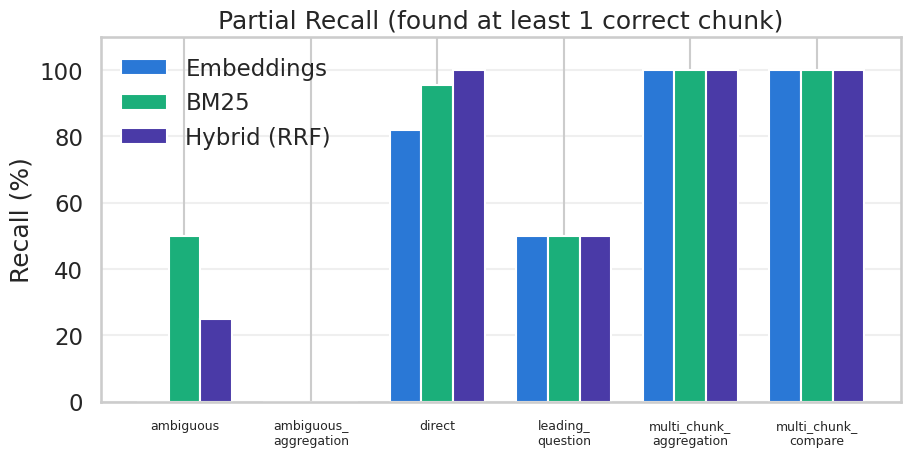

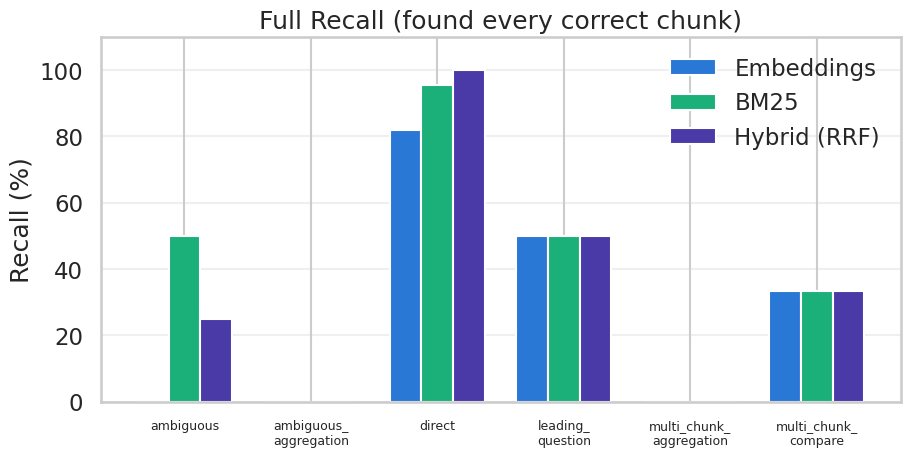

In [86]:
import matplotlib.pyplot as plt
import numpy as np

categories = ["ambiguous", "ambiguous_\naggregation", "direct", "leading_\nquestion", "multi_chunk_\naggregation", "multi_chunk_\ncompare"]

partial = {
    "Embeddings": [0, 0, 81.8, 50, 100, 100],
    "BM25": [50, 0, 95.5, 50, 100, 100],
    "Hybrid (RRF)": [25, 0, 100, 50, 100, 100],
}
full = {
    "Embeddings": [0, 0, 81.8, 50, 0, 33.3],
    "BM25": [50, 0, 95.5, 50, 0, 33.3],
    "Hybrid (RRF)": [25, 0, 100, 50, 0, 33.3],
}

def plot_recall(data, title, filename):
    x = np.arange(len(categories))
    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, data["Embeddings"], width, label="Embeddings", color="#2a78d6")
    ax.bar(x, data["BM25"], width, label="BM25", color="#1baf7a")
    ax.bar(x + width, data["Hybrid (RRF)"], width, label="Hybrid (RRF)", color="#4a3aa7")
    ax.set_ylabel("Recall (%)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.subplots_adjust(left=0.1, bottom=0.15)
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

plot_recall(partial, "Partial Recall (found at least 1 correct chunk)", "partial_recall.png")
plot_recall(full, "Full Recall (found every correct chunk)", "full_recall.png")

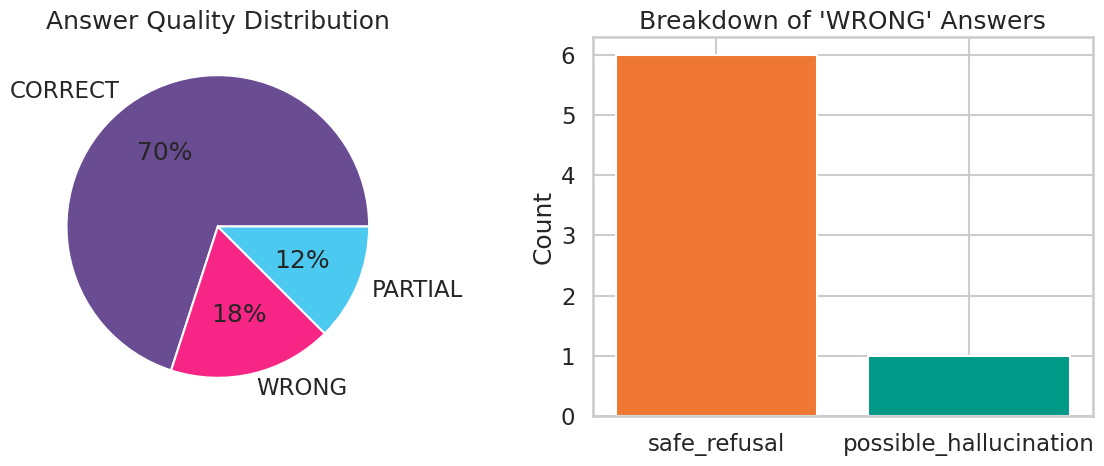

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

judgment_counts = eval_df["judgement"].value_counts()
axes[0].pie(judgment_counts, labels=judgment_counts.index, autopct="%1.0f%%",
            colors = ["#6A4C93", "#F72585", "#4CC9F0"])
axes[0].set_title("Answer Quality Distribution")

wrong_type_counts = eval_df["wrong_type"].dropna().value_counts()
axes[1].bar(wrong_type_counts.index, wrong_type_counts.values, color=["#EE7733", "#009988"])
axes[1].set_title("Breakdown of 'WRONG' Answers")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("answer_quality_breakdown.png", dpi=150)
plt.show()

# ALL DONE!!!